# ***循环平稳分析***

In [2]:
import numpy as np#数值计算库
from numpy import random#随机数库

from matplotlib import pyplot as plt#绘图库
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import pandas as pd#数据处理库

import scipy#信号处理库
from scipy.signal import sawtooth
from scipy.signal import butter, lfilter
from scipy.fft import fft
from scipy.signal import argrelextrema

import xcw_package as xcw#自定义信号处理库

from CRWU import CRWU_readdata#CRWU数据集
from CRWU import CRWU_CalFCF

In [3]:
#循环谱分解
def p_a(x,alpha,Fs):
    T = len(x) / Fs
    t = np.arange(0, T, 1/Fs)#时间离散化
    res=np.zeros(len(alpha),dtype=complex)
    for i,a in enumerate(alpha):
        res[i]=np.mean(x* np.exp(-1j * 2 * np.pi * a* t))#计算alpha循环频率处时间平均
    return res

def _p_a(x,alpha,Fs):
    df=Fs/len(x)#频率分辨率
    N=len(x)
    data=fft(x)/N

    index=(alpha/df).astype(int)#待抽取的频率索引
    res=data[[i in index for i in range(N)]]#从DFT结果中抽取alpha频率成分
    return res


#带通滤波
def bandpass(data,center_f,bandwidth, fs,order=7):
    nyq = 0.5 * fs
    low = (center_f-bandwidth/2) / nyq
    high = (center_f+bandwidth/2)  / nyq
    b, a = butter(order, [low, high], btype='band')
    y=lfilter(b, a, data)
    return y

#峰值检测
def plot_findpeak(data,values,threshold):
    if len(data)!=len(values):
        raise ValueError('data和values长度不一致')
    #寻找峰值
    peak=argrelextrema(data,np.greater)
    peak_amplitude=data[peak]
    peak_values=values[peak]
    #阈值筛选
    peak_values=peak_values[peak_amplitude>threshold]
    peak_amplitude=peak_amplitude[peak_amplitude>threshold]
    #绘图指示峰值
    plt.figure(figsize=(10,5))
    plt.plot(values,data)
    for val,amp in zip(peak_values,peak_amplitude):
        plt.annotate(f'{val:.1f}',(val,amp),textcoords="offset points",xytext=(0,10),ha='center')  
    plt.show()

# 导入数据

In [4]:
data=CRWU_readdata('DE12K','OR','21','1','6')

该实验转速参数:1771rpm
驱动端DE数据长度:121991
风扇端FE数据长度:121991
基座BA数据长度:121991


In [5]:
CRWU_CalFCF(7.94,39.04,9,1774/60)

{'BPFO': 105.99013831967213,
 'BPFI': 160.1098616803279,
 'BSF': 2.3567477133831605,
 'FTF': 11.776682035519125}

信号长度: 121991
采样频率: 12000.0 Hz
采样间隔: 0.000083 s
信号采样时长: 10.165 s
频谱频率分辨率: 0.098 Hz
可分析频率上限: 6000.0 Hz



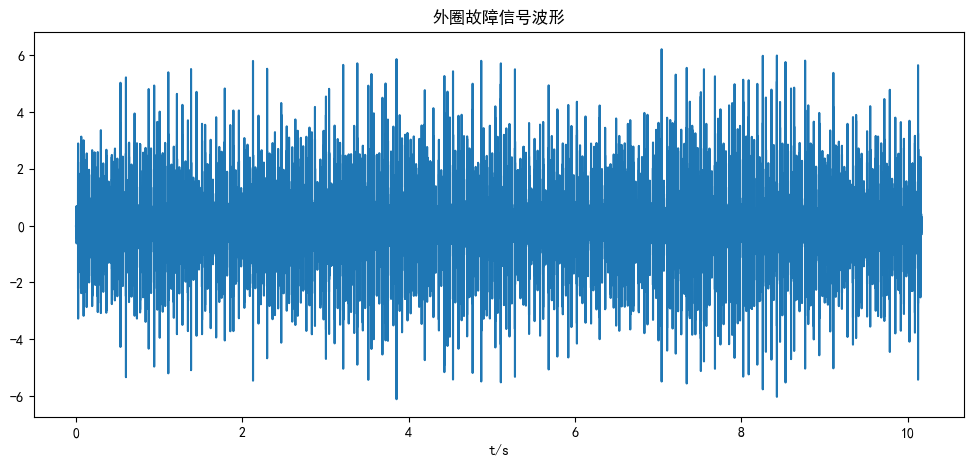

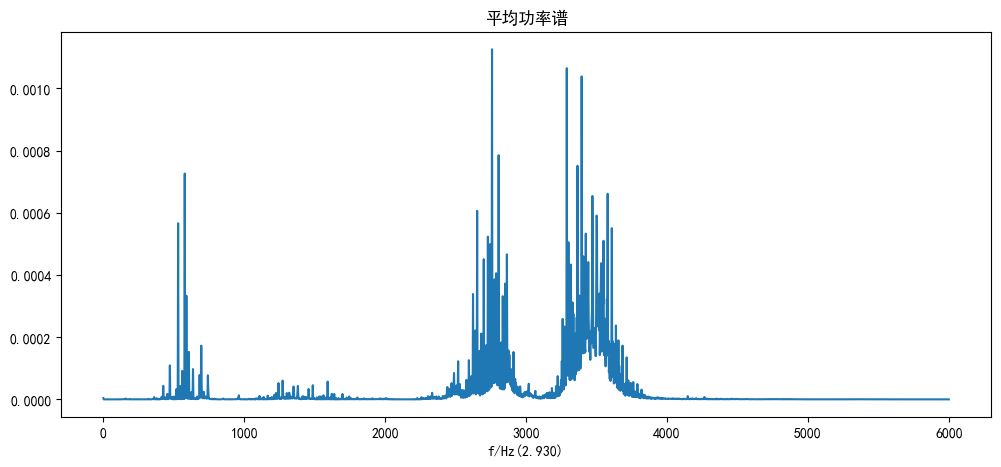

In [6]:
Sig=xcw.Signal(data['DE'],f_s=12000)
Sig.info()
Sig.plot(title='外圈故障信号波形')
xcw.plot_powerspectrum(Sig,nperseg=4096,density=True)

重采样

信号长度: 12000
采样频率: 12000.0 Hz
采样间隔: 0.000083 s
信号采样时长: 1.000 s
频谱频率分辨率: 1.000 Hz
可分析频率上限: 6000.0 Hz



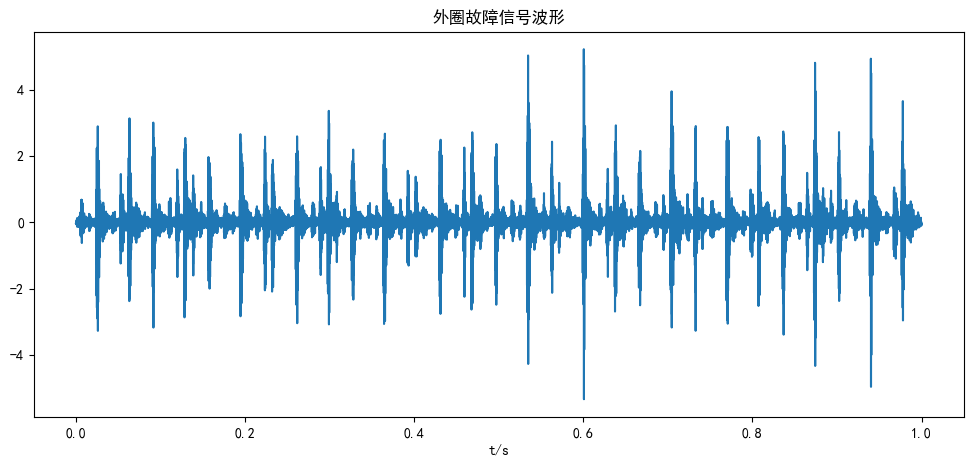

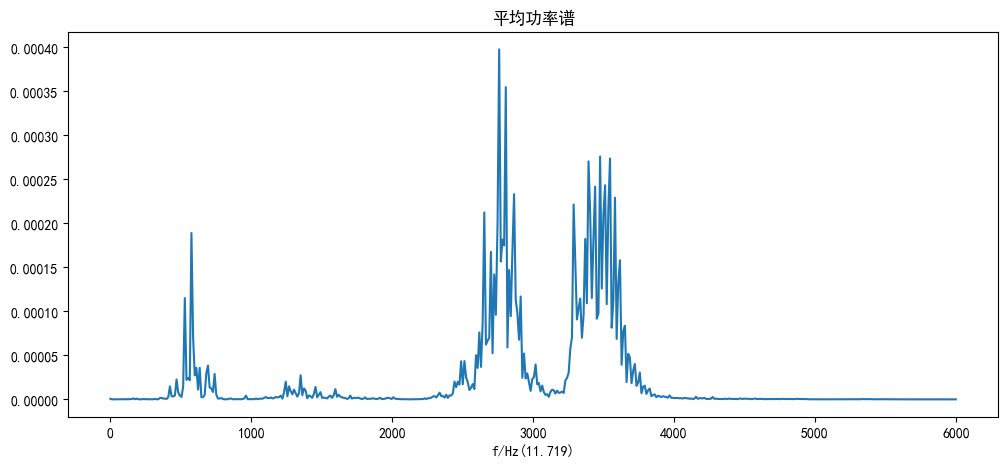

In [7]:
stSig=xcw.resample(Sig,12000,12000)
stSig.info()
stSig.plot(title='外圈故障信号波形')
xcw.plot_powerspectrum(stSig,1024,density=True)

# 循环功率分析

In [100]:
alpha=np.arange(0,200,1)
data=Sig.data
ctr_f=np.arange(2000,4000,20)
P=np.zeros((len(ctr_f),len(alpha)))
for i,f in enumerate(ctr_f):
    bpdata=bandpass(data,f,200,Sig.f_s)
    sqrdata=np.square(bpdata)
    P[i]=np.abs(p_a(sqrdata,alpha,Sig.f_s))

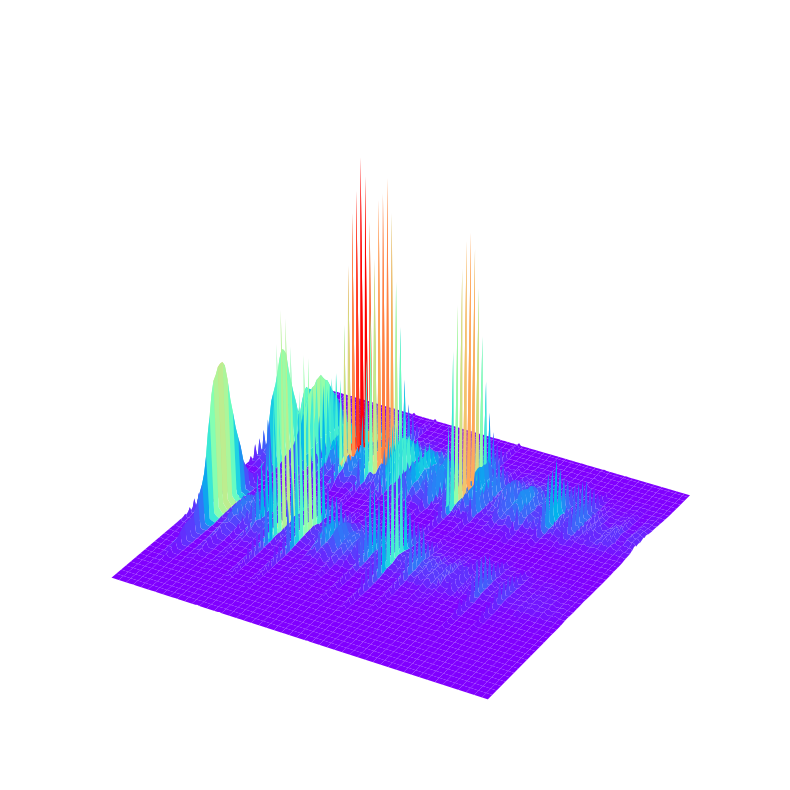

In [136]:
P[:,0]=0
X,Y=np.meshgrid(alpha,ctr_f)
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,P,cmap='rainbow')
ax.set_xlabel('循环频率/Hz')
ax.set_ylabel('谱频率/Hz')
ax.set_axis_off()
plt.show()

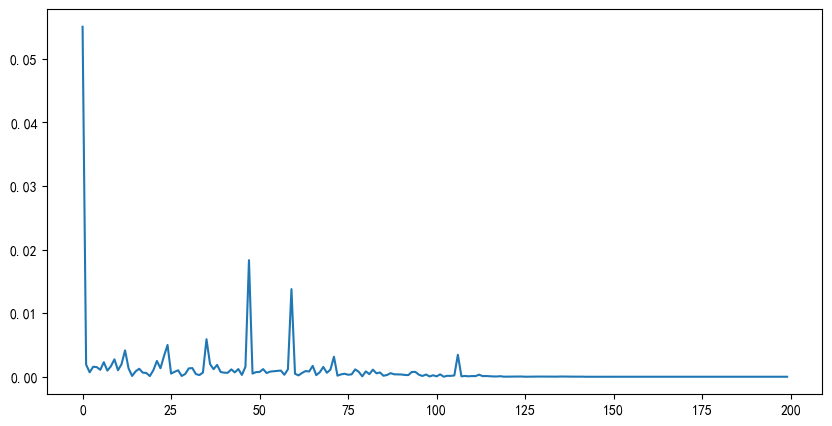

In [76]:
bpdata=bandpass(Sig.data,3450,100,Sig.f_s)
bpSig=xcw.Signal(bpdata,f_s=Sig.f_s)
_P=np.abs(p_a(np.square(bpdata),alpha,Sig.f_s))
plt.figure(figsize=(10,5))
plt.plot(alpha,_P)
plt.show()

# 循环自相关分析

In [111]:
alpha=np.arange(0,500,1)#循环频率取值
tau=np.arange(0,0.2,stSig.dt)#时延取值
R=np.zeros((len(tau),len(alpha)),dtype=complex)#循环自相关
data=np.zeros((len(tau),stSig.N))
for i,t in enumerate(tau):
    data[i]=np.roll(stSig.data,int(t/stSig.dt))*stSig.data#计算时延乘积，即对信号的二阶非线性运算

In [112]:
for i in range(len(tau)):
    R[i]=_p_a(data[i],alpha,12000)#对信号二阶运算结果作循环谱分解，得到循环自相关

R=np.abs(R)

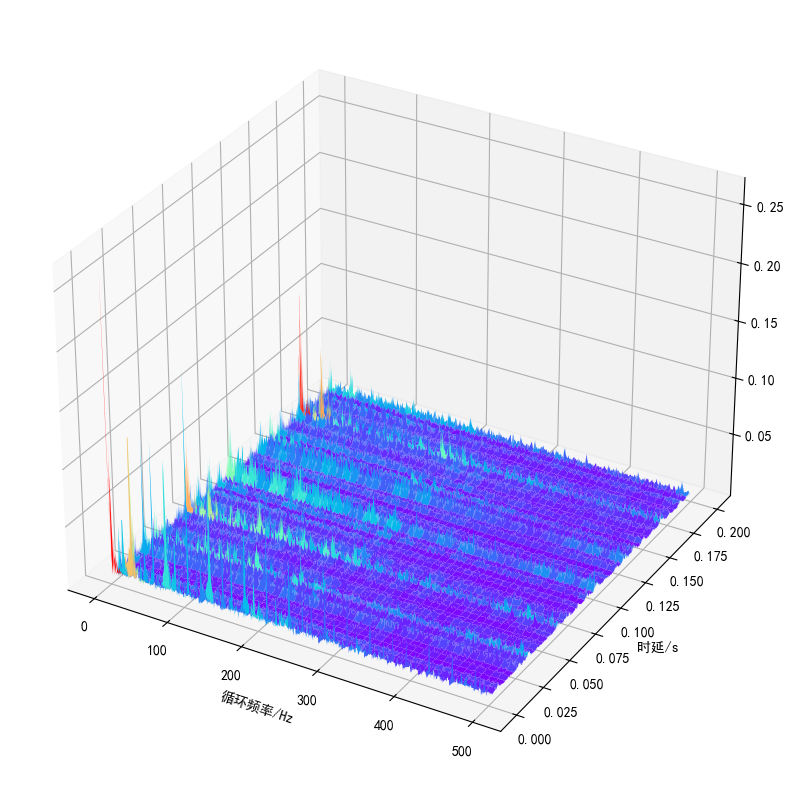

In [120]:
X,Y=np.meshgrid(alpha,tau)
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,R,cmap='rainbow')
ax.set_xlabel('循环频率/Hz')
ax.set_ylabel('时延/s')
plt.show()

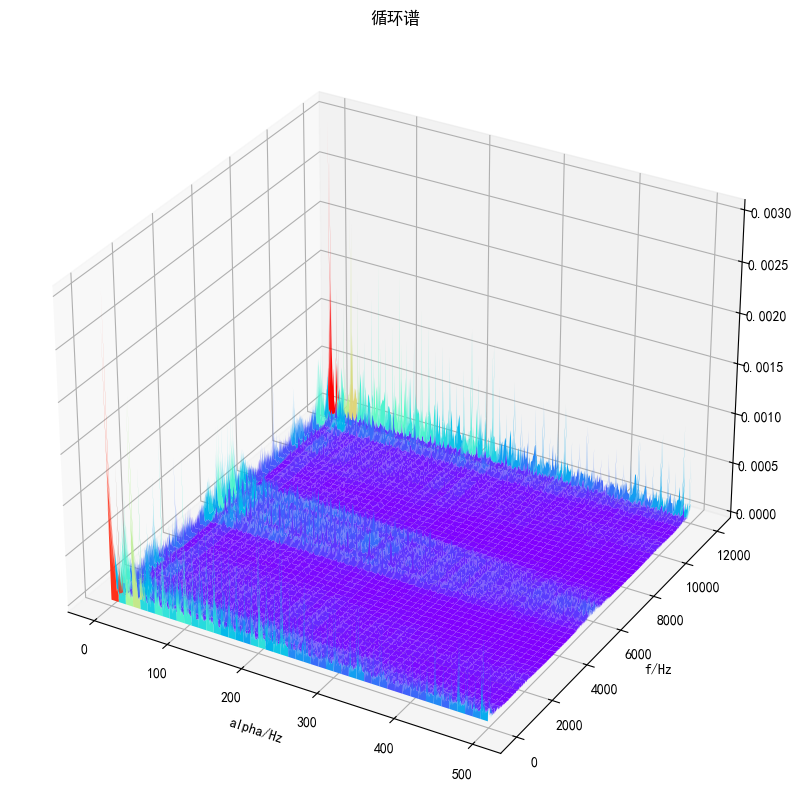

In [162]:
S=np.zeros((len(tau),len(alpha)),dtype=float)
for a in alpha:
    S[:,a]=np.abs(fft(R[:,a])/len(tau))

S[0,:]=0
# S=S[:100,:]
X,Y=np.meshgrid(alpha,np.arange(0,5*len(tau),5))#生成网格
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(X,Y,S,cmap='rainbow')
plt.ylabel('f/Hz')
plt.xlabel('alpha/Hz')
plt.title('循环谱')
plt.show()